In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# initialize config
latent_feature_path = '/home/rachel/Desktop/drosophila_sleep_analysis/ld20_std10_1000ep/latent_variables_epoch1000.csv'
original_agg_path = '/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_standardized_binned.csv'
shap_importance_path = '/home/rachel/Desktop/drosophila_sleep_analysis/binned_beam_break/mlp_ld20_std10_1000ep/shap_importance.csv'
saved_model_path = '/home/rachel/Desktop/drosophila_sleep_analysis/ld20_std10_1000ep/saved_model_epoch1000.pth'
output_path = '/home/rachel/Desktop/drosophila_sleep_analysis/binned_beam_break/mlp_ld20_std10_1000ep/'
# col_means_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data/agg_mean.csv'
# col_std_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data/agg_std.csv'

# initialize other relevant parameters
data_type = 'raw' # raw or agg 
num_original_features = 5017
num_conditions = 2
num_latent_features = 20

In [4]:
latent_features = pd.read_csv(latent_feature_path)
latent_features

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV14,LV15,LV16,LV17,LV18,LV19,LV20,flyID,genotype,ad_label
0,-25.398653,-20.167301,-16.856117,-20.492540,-21.937586,-25.840948,-21.530788,-10.496050,-26.627789,-16.687443,...,-14.130101,-27.838943,-19.280191,-23.733294,-17.461645,-21.251432,-13.443365,M106_M25_Ch1,SwedArcxattp2_3_M,0
1,4.467230,-8.056909,-3.804221,-8.069091,-13.292306,-1.545249,-6.180738,-5.854238,-10.369992,-1.232515,...,-4.907227,0.428388,4.124784,-0.394359,-13.842321,-6.089891,-4.960381,M106_M118_Ch4,Londonxalrm_3_F,1
2,3.058420,-6.615629,-1.446524,-5.080868,-11.329257,-7.441734,-9.089117,-7.106611,-10.073233,0.278066,...,-0.631606,4.401161,-0.330822,0.156574,-10.070155,-1.477690,-10.422681,M106_M15_Ch11,SwedArcxrepo_3_F,1
3,1.815826,-7.346237,-2.363455,-7.020743,-14.723239,-10.710448,-11.324224,-2.570051,-10.347515,0.160390,...,-3.468807,1.065743,-6.751969,-1.655219,-6.689716,-3.648693,-11.247424,M119_M50_Ch6,elavQFxQAb40_F,1
4,-9.639016,-17.644205,-8.752705,-9.419070,-11.148856,-14.905492,-7.681318,-7.196809,-20.760374,-8.793821,...,-11.172872,-9.717279,-12.625588,-13.486639,-9.186372,-6.986126,-14.070205,M96_M29_Ch31,attp2>nsybG4F,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,-18.552614,-16.623322,-14.171892,-19.950450,-16.152597,-24.505842,-15.525447,-11.299481,-22.542759,-11.760922,...,-18.008528,-25.740400,-18.648438,-22.928255,-16.026310,-17.025856,-17.672010,M106_M30_Ch4,attp2xQA40_1_M,0
1202,-9.843765,-12.188805,-12.087719,-13.484781,-11.355681,-13.518781,-9.081827,-13.058561,-15.949013,-6.719620,...,-10.250587,-14.055189,-11.931550,-13.809509,-10.962068,-9.058375,-13.648627,M106_M115_Ch28,Londonxattp40_3_F,0
1203,-17.653540,-14.670520,-12.457571,-18.513803,-18.056627,-21.577263,-13.763947,-15.265335,-19.599428,-8.984156,...,-14.568480,-19.596676,-16.594604,-17.814730,-14.961314,-12.931335,-9.694328,M106_M111_Ch31,attp40xQA42_1_F,0
1204,-1.712500,-6.399164,-5.237992,-5.264272,-8.948391,-7.202127,-11.602809,-5.938529,-10.010715,-0.974382,...,-1.754144,0.524446,-0.139317,-4.617484,-8.193037,-3.845401,-7.453502,M106_M15_Ch10,SwedArcxrepo_3_F,1


In [5]:
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load saved model 
vae = torch.load(saved_model_path, map_location=device, weights_only=False)
vae.eval()

CGMVAE(
  (label): Embedding(2, 1)
  (fc1): Linear(in_features=5018, out_features=2048, bias=True)
  (bn1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc21): Linear(in_features=2048, out_features=40, bias=True)
  (fc22): Linear(in_features=2048, out_features=40, bias=True)
  (fc3): Linear(in_features=21, out_features=2048, bias=True)
  (bn3): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=2048, out_features=5017, bias=True)
)

In [6]:
# col_means_df = pd.read_csv(col_means_path)
# col_means = torch.tensor(col_means_df.iloc[:, 0].values, dtype=torch.float32).to(device)
# col_std_df = pd.read_csv(col_std_path)
# col_std = torch.tensor(col_std_df.iloc[:, 0].values, dtype=torch.float32).to(device)
original_data = pd.read_csv(original_agg_path)
if data_type == 'agg':
    columns_ordered = original_data.iloc[:, 8:].columns
else: 
    columns_ordered = original_data.iloc[:, 2:].columns 

Prepare latent data

In [7]:
latent_features_ad = latent_features.loc[latent_features['ad_label'] == 1, latent_features.columns[:num_latent_features]]
latent_features_nonad = latent_features.loc[latent_features['ad_label'] == 0, latent_features.columns[:num_latent_features]]
latent_features_comb = [latent_features_nonad, latent_features_ad]

In [8]:
mean_latent_features_ad = latent_features_ad.mean()
mean_latent_features_nonad = latent_features_nonad.mean()
mean_latent_features = np.vstack([mean_latent_features_nonad, mean_latent_features_ad])

In [9]:
def decode_traversal(traversal_tensor, label_tensor):
    with torch.no_grad():
        recon_standardized = vae.decode(traversal_tensor, label_tensor)
        #recon = recon_standardized * col_means + col_std
    return torch.abs(recon_standardized[0] - recon_standardized[1])

In [10]:
importance_values = []
for cond in range(num_conditions):
    mean_lv = mean_latent_features[cond]
    abs_diff_cond = []
    for lv in range(num_latent_features):
        max_latent_value = max(latent_features_comb[cond].iloc[:, lv])
        min_latent_value = min(latent_features_comb[cond].iloc[:, lv])
        traversal_input = np.vstack([mean_lv, mean_lv])
        traversal_input[0][lv] = max_latent_value
        traversal_input[1][lv] = min_latent_value
        #print('final traversal input')
        #print(traversal_input)
        traversal_tensor = torch.tensor(traversal_input, dtype=torch.float32).to(device)
        #print(traversal_tensor)
        label_tensor = torch.tensor(np.ones(2), dtype=torch.long).to(device)
        #print(label_tensor)
        abs_diff = decode_traversal(traversal_tensor, label_tensor)
        abs_diff_cond.append(abs_diff)
    abs_diff_stacked = torch.stack(abs_diff_cond)
    importance_values.append(abs_diff_stacked)
avg_across_cond = torch.stack(importance_values).mean(dim=0)
print(avg_across_cond.shape)
print(avg_across_cond)

torch.Size([20, 5017])
tensor([[0.0512, 0.0942, 0.0570,  ..., 1.6134, 1.5872, 2.1001],
        [0.0360, 0.0311, 0.0442,  ..., 0.2732, 1.2744, 1.7460],
        [0.0672, 0.0931, 0.0875,  ..., 1.1266, 0.5271, 0.9568],
        ...,
        [0.0878, 0.2171, 0.0738,  ..., 0.3418, 0.7254, 0.8004],
        [0.0259, 0.0224, 0.0259,  ..., 0.5783, 0.6642, 0.2910],
        [0.0266, 0.0372, 0.0384,  ..., 0.5974, 0.2589, 0.5144]],
       device='cuda:0')


In [12]:
len(importance_values)

2

Compile individual latent feature components and multiply by SHAP weight

In [ ]:
shap_importance = pd.read_csv(shap_importance_path)
shap_importance_torch = torch.tensor(shap_importance['Feature Weight'].values, dtype=torch.float32).to(device)
shap_importance_torch

tensor([6.3938e-02, 2.4985e-02, 4.9824e-02, 4.1272e-02, 8.8221e-03, 3.2743e-04,
        2.9796e-02, 4.2700e-04, 1.2674e-02, 1.5001e-01, 8.0844e-05, 1.6389e-02,
        4.5518e-03, 2.8340e-02, 7.5806e-04, 7.6721e-02, 1.5800e-02, 3.4808e-04,
        1.4797e-03, 2.3570e-03], device='cuda:0')

In [ ]:
avg_across_cond

tensor([[0.0512, 0.0942, 0.0570,  ..., 1.6134, 1.5872, 2.1001],
        [0.0360, 0.0311, 0.0442,  ..., 0.2732, 1.2744, 1.7460],
        [0.0672, 0.0931, 0.0875,  ..., 1.1266, 0.5271, 0.9568],
        ...,
        [0.0878, 0.2171, 0.0738,  ..., 0.3418, 0.7254, 0.8004],
        [0.0259, 0.0224, 0.0259,  ..., 0.5783, 0.6642, 0.2910],
        [0.0266, 0.0372, 0.0384,  ..., 0.5974, 0.2589, 0.5144]],
       device='cuda:0')

In [ ]:
weighted_avg = shap_importance_torch @ avg_across_cond

In [ ]:
weighted_avg

tensor([0.0182, 0.0294, 0.0169,  ..., 0.5709, 0.4153, 0.5670], device='cuda:0')

In [ ]:
traversal_results =  pd.Series(weighted_avg.detach().cpu().numpy(), index=columns_ordered).sort_values(ascending=False)

In [ ]:
print('Feature relevance in descending order')
print(traversal_results)

Feature relevance in descending order
t483     1.429991
t482     1.418016
t662     1.399307
t481     1.375917
t1742    1.329955
           ...   
t9       0.018170
t10      0.017613
t18      0.017318
t2       0.016939
t7       0.014867
Length: 5017, dtype: float32


In [ ]:
traversal_results.to_csv(os.path.join(output_path, 'traversal_results.csv'))

Plot relevance over time according to light phases

In [ ]:
timed_relevance = pd.DataFrame(weighted_avg.cpu().numpy())
timed_relevance

,0
0,0.018235
1,0.029438
2,0.016939
3,0.029967
4,0.020176
...,...
5012,0.464880
5013,0.722352
5014,0.570885
5015,0.415266


In [ ]:
timed_relevance.to_csv(os.path.join(output_path, 'relevance_ordered.csv'), index=False)

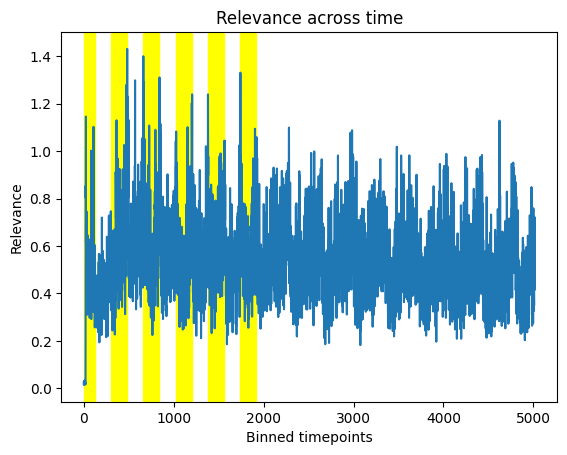

In [ ]:
# plot light cycle
light_cycle = ([0, 480], [1200, 1920], [2640, 3360], [4080, 4800], [5520, 6240], [6960, 7680]) 
fig, ax = plt.subplots()
ax.plot(timed_relevance)
ax.set_title('Relevance across time')
ax.set_xlabel('Binned timepoints')
ax.set_ylabel('Relevance')
for i, (start, end) in enumerate(light_cycle):
    ax.axvspan(start / 4, end / 4, color='yellow', label = 'light')

Text(0, 0.5, 'Relevance')

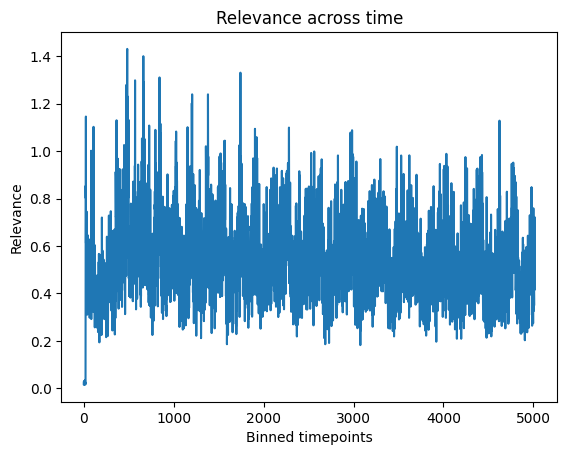

In [ ]:
plt.plot(timed_relevance)
plt.title('Relevance across time')
plt.xlabel('Binned timepoints')
plt.ylabel('Relevance')